# Проектная работа по теме: "Принятие решений в бизнесе"

**Описание проекта**\
 Я — аналитик крупного интернет-магазина. Вместе с отделом маркетинга мы подготовили список гипотез для увеличения выручки.

**Цель исследования:**\
приоритизировать гипотезы, запустить A/B-тест и проанализировать результаты. 
<br>
<br>

 **Описание данных:**\
Данные для первой части - датасет /datasets/hypothesis.csv с девятью гипотезами по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort.\
Данные для второй части - датасеты /datasets/orders.csv и /datasets/visitors.csv с данными A/B-теста и полученными результатами.
<br>
<br>

**Задачи исследования**:

Часть 1. Приоритизация гипотез.
1) приоритизировать гипотезы через фреймворки ICE и RICE;\
2) объяснить как изменилась приоритизация гипотез при применении RICE вместо ICE.
<br>

Часть 2. Анализ A/B-теста.
1) построить графики кумулятивной выручки, кумулятивного среднего чека и кумулятивного среднего количества заказов на посетителя  по группам, сделать выводы и предположения;\
2) построить графики относительного изменения кумулятивного среднего чека и относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A, сделать выводы и предположения;\
3) построить точечные графики количества заказов по пользователям и стоимостей заказов, сделать выводы и предположения;\
4) посчитать 95-й и 99-й перцентили количества заказов на пользователя и стоимости заказов, выбрать границу для определения аномалий;\
5) посчитать статистическую значимость различий и сделать выводы и предположения:
- в среднем количестве заказов на посетителя между группами по «сырым» данным
- в среднем чеке заказа между группами по «сырым» данным
- в среднем количестве заказов на посетителя между группами по «очищенным» данным
- в среднем чеке заказа между группами по «очищенным» данным\

6) принять решение по результатам теста и объяснить его.
<br>
<br>

**План исследования:**
1) загрузка данных, изучение общей информации, предобработка;\
2) часть 1 - приоритизация гипотез;\
3) часть 2 - анализ A/B-теста;\
4) общий вывод.


In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import scipy.stats as stats

### Загрузка данных и подготовка их к анализу

#### Загрузка данных

In [2]:
# сохраняем датафрейм с информацией о гипотезах по увеличению выручки
try:
    hypothesis = pd.read_csv('/datasets/hypothesis.csv')
except:
    hypothesis = pd.read_csv('https://code.s3.yandex.net/datasets/hypothesis.csv')
pd.set_option('max_colwidth', 120)
pd.set_option('display.width', 500)
    
# сохраняем датафреймы с информацией об A/B-тесте и полученных результатах:
# с заказами
try:
    orders = pd.read_csv('/datasets/orders.csv')
except:
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders.csv')

# с пользователями 
try:
    visitors = pd.read_csv('/datasets/visitors.csv')
except:
    visitors = pd.read_csv('https://code.s3.yandex.net/datasets/visitors.csv')


#### Общая информация

In [3]:
# смотрим основную информацию датафрейма hypothesis
display(hypothesis.head())
print()
hypothesis.info()

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


Нужно переименовать столбцы, используя стиль snake case. 

In [4]:
# переименовываем столбцы в датафрейме hypothesis
hypothesis.columns = [x.lower().replace(' ', '_') for x in hypothesis.columns.values]
hypothesis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [5]:
# смотрим основную информацию датафрейма orders
display(orders.head())
print()
orders.info()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


Необходимо:
1) переименовать столбцы, используя стиль snake case;\
2) изменить тип данных столбца date на datetime.

In [6]:
# переименовываем столбцы в датафрейме orders
orders.columns = ['transaction_id', 'visitor_id'] + list(orders.columns[2:])

# меняем тип данных в столбце date на datetime
orders['date'] = pd.to_datetime(orders['date'])

# проверяем
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   int64         
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


In [7]:
# смотрим основную информацию датафрейма visitors
display(visitors.head())
print()
visitors.info()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


Необходимо изменить тип данных столбца date на datetime.

In [8]:
# меняем тип данных в столбце date на datetime
visitors['date'] = pd.to_datetime(visitors['date'])

# проверяем
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


#### Обработка пропусков

In [9]:
# выводим количество пропущенных значений для каждого столбца датафрейма hypothesis
print(hypothesis.isna().sum())
print()

# выводим количество пропущенных значений для каждого столбца датафрейма orders
print(orders.isna().sum())
print()

# выводим количество пропущенных значений для каждого столбца датафрейма visitors
print(visitors.isna().sum())

hypothesis    0
reach         0
impact        0
confidence    0
efforts       0
dtype: int64

transaction_id    0
visitor_id        0
date              0
revenue           0
group             0
dtype: int64

date        0
group       0
visitors    0
dtype: int64


Пропусков в датафреймах нет.

#### Обработка дубликатов

In [10]:
# проверяем на наличие явных дубликатов датафрейм hypothesis
print(hypothesis.duplicated().sum())
print()

# проверяем на наличие явных дубликатов датафрейм orders
print(orders.duplicated().sum())
print()

# проверяем на наличие явных дубликатов датафрейм visitors
print(visitors.duplicated().sum())
print()


0

0

0



Явных дубликатов нет.

**Проверяем на наличие неявных дубликатов:**

In [11]:
# проверяем на наличие неявных дубликатов датафрейм hypothesis столбец hypothesis
print(hypothesis['hypothesis'].unique())

['Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей'
 'Запустить собственную службу доставки, что сократит срок доставки заказов'
 'Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа'
 'Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар'
 'Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей'
 'Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов'
 'Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию'
 'Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок'
 'Запустить акцию, дающую скидку на товар в день рождения']


Неявные дубликаты не были обнаружены.

#### Вывод

На этапе предобработки было сделано следующее:
1) изменение названий столбцов в соответствии с общепринятым стилем;\
2) изменение типа данных object на datetime в столбцах с датой и временем;\
3) проверка на пропуски, явные и неявные дубликаты - таковых обнаружено не было.

### Часть 1. Приоритизация гипотез

#### Фреймворк ICE

In [12]:
# применим фреймворк ICE для приоритизации гипотез
hypothesis['ICE'] = (hypothesis['impact'] * hypothesis['confidence']/hypothesis['efforts']).round(2)
hypothesis = hypothesis.sort_values(by='ICE', ascending=False)
display(hypothesis)

,hypothesis,reach,impact,confidence,efforts,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


#### Фреймворк RICE

In [13]:
# применим фреймворк RICE для приоритизации гипотез
hypothesis['RICE'] = (hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence']/hypothesis['efforts']).round(2)
hypothesis = hypothesis.sort_values(by='RICE', ascending=False)
display(hypothesis)

,hypothesis,reach,impact,confidence,efforts,ICE,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.0


#### Вывод

В топ-5 приоритетных гипотез по методу ICE Score входят гипотезы под номерами: 8, 0, 7, 6, 2 в указанном порядке по убыванию приоритетности.\
В то время как в топ-5 приоритетных гипотез по методу RICE Score входят гипотезы под номерами: 7, 2, 0, 6, 8.\
Наборы приоритетных гипотез схожи, следовательно, остальные гипотезы (1, 3, 4, 5) исключаются из списка гипотез для проведения дальнейших тестов или откладываются из-за своей нецелесообразности.

Гипотезы после приоритизации обоими методами поменяли свои места в топ-5:
- Гипотеза 8: вместо 1-го места по ICE сместилась на 5-е по RICE.
- Гипотеза 0: вместо 2-го места сместилась на 3-е.
- Гипотеза 7: вместо 3-го места поднялась на 1-е.
- Гипотеза 6: осталась на 4-м месте без изменений.
- Гипотеза 2: вместо 5-го места поднялась на 2-е.

Изменение приоритетов гипотез связано с тем, что при приоритизации по методу RICE, кроме параметров Impact (влияние изменения), Confidence (уверенность в том, как повлияет изменение) и Efforts (стоимость тестирования гипотезы), учитывается еще параметр Reach, который обозначает обхват пользователей, которых затронет изменение. Следовательно, RICE Score предоставляет более полный анализ, чем ICE Score.

### Часть 2. Анализ A/B-теста

In [14]:
# проверим, что пользователи не попали в обе группы сразу
user_group_counts = orders.groupby('visitor_id')['group'].nunique().reset_index()
user_group_counts.columns = ['visitor_id', 'groups']
users_with_multiple_groups = user_group_counts[user_group_counts['groups'] == 2]
print(users_with_multiple_groups.head())
print()
print(users_with_multiple_groups.count())

    visitor_id  groups
2      8300375       2
44   199603092       2
51   232979603       2
55   237748145       2
66   276558944       2

visitor_id    58
groups        58
dtype: int64


58 пользователей попали в обе группы.

#### График кумулятивной выручки по группам

In [17]:
# объединим таблицы orders и visitors в одну
# для этого создадим массив уникальных пар значений дат и групп теста
datesGroups = orders[['date', 'group']].drop_duplicates()

In [18]:
# для наглядности имеющихся данных и дальнейшей работы с кодом
display(datesGroups.head())
display(orders.head())
display(visitors.head())

,date,group
0,2019-08-15,B
2,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B
55,2019-08-01,A


,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [19]:
# получим агрегированные кумулятивные по дням данные о заказах 
ordersAggregated = datesGroups.apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]\
                        .agg({'date' : 'max', 'group' : 'max', 'transaction_id' : 'nunique', 'visitor_id' : 'nunique', 'revenue' : 'sum'}), axis=1)\
                        .sort_values(by=['date','group'])
# получим агрегированные кумулятивные по дням данные о посетителях интернет-магазина 
visitorsAggregated = datesGroups.apply(lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], visitors['group'] == x['group'])]\
                        .agg({'date' : 'max', 'group' : 'max', 'visitors' : 'sum'}), axis=1)\
                        .sort_values(by=['date','group'])
cumulativeData = ordersAggregated.merge(visitorsAggregated, on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']
print(cumulativeData.head())

        date group  orders  buyers  revenue  visitors
0 2019-08-01     A      24      20   148579       719
1 2019-08-01     B      21      20   101217       713
2 2019-08-02     A      44      38   242401      1338
3 2019-08-02     B      45      43   266748      1294
4 2019-08-03     A      68      62   354874      1845


In [20]:
# создаем таблицы с группой A и группой B
cumulativeRevenueA = cumulativeData[cumulativeData['group'] == 'A'][['date','revenue', 'orders']]
cumulativeRevenueB = cumulativeData[cumulativeData['group'] == 'B'][['date','revenue', 'orders']]

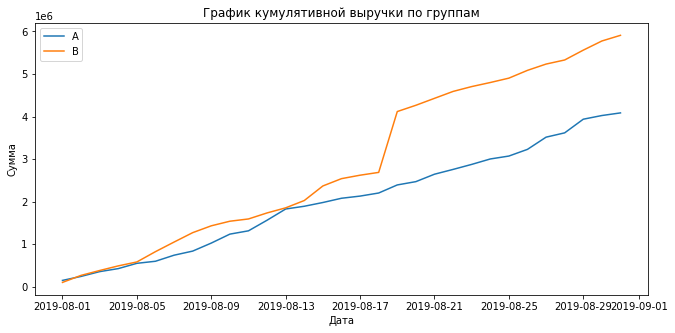

In [21]:
# построим графики кумулятивной выручки по группам 
plt.figure(figsize=(11, 5))

# строим график выручки группы А
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')

# строим график выручки группы B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Сумма')
plt.title('График кумулятивной выручки по группам')
plt.show()

По кумулятивной выручке группа B лидирует на протяжении всего периода.\
И выручка обеих групп растет почти равномерно в течение времени, но около 18 августа 2019 года график выручки группы B демонстрирует резкий скачок вверх. Этот скачок может указывать на внезапное увеличение числа заказов или на появление очень крупных заказов в выборке.

#### График кумулятивного среднего чека по группам

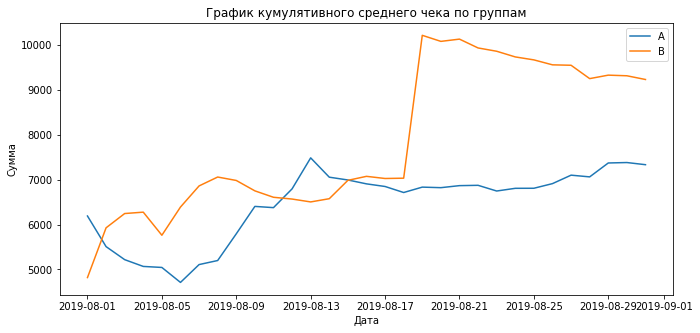

In [22]:
# построим график кумулятивного среднего чека по группам
plt.figure(figsize=(11, 5))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Сумма')
plt.title('График кумулятивного среднего чека по группам')
plt.show()

Графики почти выровнялись после середины периода, для группы A он незначительно плавно растет, а для группы B снижается после резкого скачка примерно 18 августа 2019 года. Это может говорить о том, что в этот день попались очень крупные и/или дорогие заказы или повлияли другие факторы (распродажа, введение новых товаров, увеличение цен). Нужно это проанализировать.

#### График относительного изменения кумулятивного среднего чека группы B к группе A

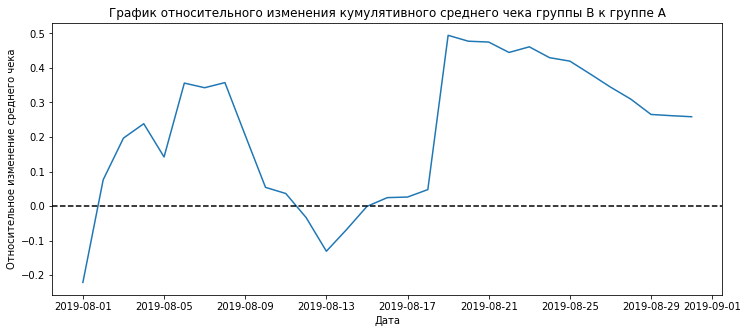

In [23]:
# строим график относительного изменения кумулятивного среднего чека группы B к группе A
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, on='date', how='left', suffixes=['A', 'B'])
# cтроим график отношения средних чеков
plt.figure(figsize=(12, 5))
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/\
         (mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)
# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Дата')
plt.ylabel('Относительное изменение среднего чека')
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.show(); 

В некоторые даты график резко скачет, значит, выбросы и крупные заказы точно были.\
Но в основном группа B лидирует по метрике.

#### График кумулятивного среднего количества заказов на посетителя по группам

In [24]:
# узнаем минимальную и максимальную даты для оределения границ графика
print(cumulativeData['date'].min())
print(cumulativeData['date'].max())

2019-08-01 00:00:00
2019-08-31 00:00:00


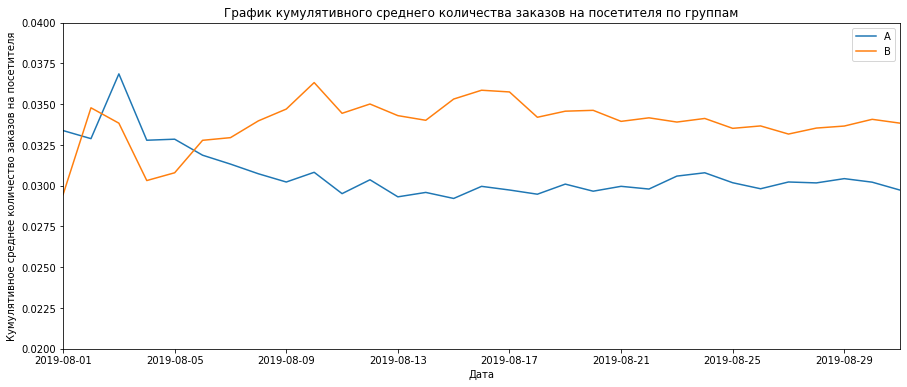

In [25]:
# построим график кумулятивного среднего количества заказов на посетителя по группам

# считаем среднее количество заказов на посетителя
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# отделяем данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# отделяем данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# строим графики
plt.figure(figsize=(15, 6))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.legend()
# задаем масштаб осей
plt.axis(["2019-08-01", '2019-08-31', 0, 0.05])
plt.ylim(0.02, 0.04)
plt.xlabel('Дата')
plt.ylabel('Кумулятивное среднее количество заказов на посетителя')
plt.title('График кумулятивного среднего количества заказов на посетителя по группам')
plt.show()

В начале периода графики колебались, но скоро у группы B среднее количество заказов вырвалось вперёд и зафиксировалось, а у группы A — незначительно просело, и тоже зафиксировалось.

#### График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

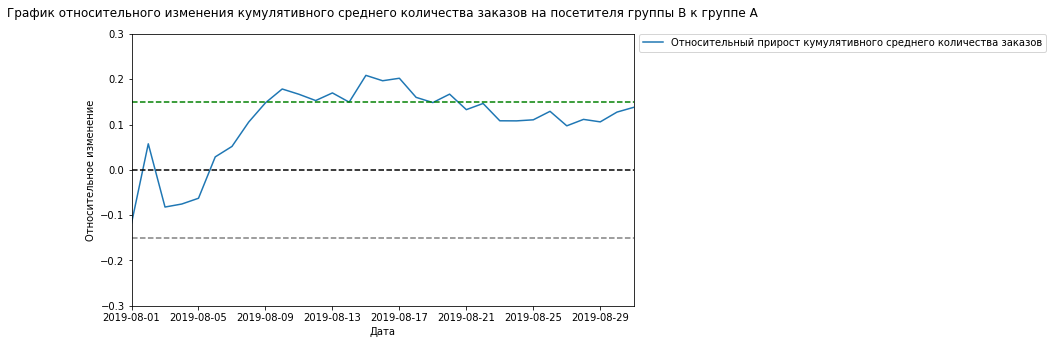

In [26]:
# построим график изменения кумулятивного среднего количества заказов на посетителя группы B к группе A:
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']],\
                                                                           left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.figure(figsize=(9, 5))
plt.plot(mergedCumulativeConversions['date'],\
         mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA']-1,\
         label="Относительный прирост кумулятивного среднего количества заказов")
plt.legend()

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=-0.15, color='grey', linestyle='--')
plt.axhline(y=0.15, color='green', linestyle='--')
plt.axis(["2019-08-01", '2019-08-31', -0.3, 0.3])
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., prop={'size': 10})
plt.xlabel('Дата')
plt.ylabel('Относительное изменение')
plt.title('График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A', pad=17)
plt.show()

В начале периода наблюдаются резкие изменения графика, но при этом по данной метрике группа B становится все лучше и очень скоро зафиксировалась на уровне около 15% прироста относительно группы A.

#### Точечный график количества заказов по пользователям

In [27]:
# подсчитаем количество заказов по пользователям
ordersByUsers = (
    orders.groupby('visitor_id', as_index=False)
    .agg({'transaction_id': 'nunique'})
)

ordersByUsers.columns = ['visitor_id', 'orders']

print(ordersByUsers.sort_values(by='orders', ascending=False).head(10)) 

      visitor_id  orders
1023  4256040402      11
591   2458001652      11
569   2378935119       9
487   2038680547       8
44     199603092       5
744   3062433592       5
55     237748145       5
917   3803269165       5
299   1230306981       5
897   3717692402       5


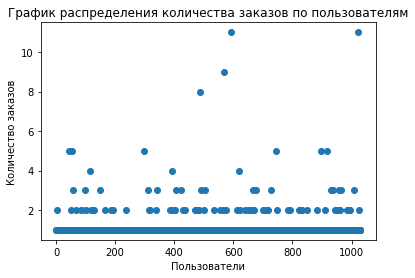

In [28]:
# построим точечный график числа заказов по пользователям
x_values = pd.Series(range(0,len(ordersByUsers)))

plt.scatter(x_values, ordersByUsers['orders'])
plt.title('График распределения количества заказов по пользователям')
plt.xlabel('Пользователи')
plt.ylabel('Количество заказов')
plt.show()

Очень много пользователей с 1-2 заказами, вопрос, считать ли пользователей с 3 и более заказами выбросами.

#### 95-й и 99-й перцентили количества заказов на пользователя

In [29]:
# посчитаем 95-й и 99-й перцентили количества заказов на пользователя
print(np.percentile(ordersByUsers['orders'], [95, 99])) 

[2. 4.]


Не более 5% пользователей оформили более 2 заказов, и не более 1% пользователей заказывали 4 и более раз.\
Тогда примем за аномалии тех пользователей, которые совершили 4 и более заказов, так мы уберём 1% пользователей с наибольшим числом заказов.

#### Точечный график стоимостей заказов

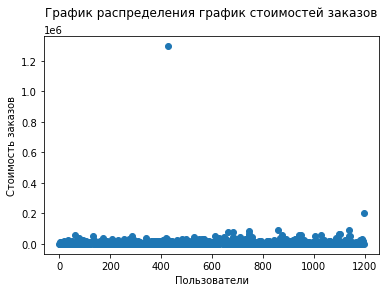

In [30]:
# построим точечный график стоимостей заказов
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue'])
plt.title('График распределения график стоимостей заказов', pad=20)
plt.xlabel('Пользователи')
plt.ylabel('Стоимость заказов')
plt.show()

Основная часть заказов имеет стоимость примерно до 100 000, но на графике видны выбросы около 200 000 и 1 300 000. 

#### 95-й и 99-й перцентили стоимости заказов

In [31]:
# посчитаем 95-й и 99-й перцентили стоимости заказов
print(np.percentile(orders['revenue'], [95, 99])) 

[28000.  58233.2]


Не более 5% заказов дороже 28 000, и не более 1% дороже 58 233.2.\
Тогда примем за аномалии заказы на сумму свыше 58 233.2, так мы уберём 1% заказов с наибольшей стоимостью.

In [32]:
display(orders.head())

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


#### Cоздание очищенных датафреймов с пользователями группы A и пользователями группы B

In [33]:
# создаем переменные для минимальных значений количества заказов и суммы заказов для пользователей,выше которых уже аномалии
orders_min = 4
revenue_min = 58233.2

# создаем два датафрейма с заказами по пользователям из группы A и пользователям из группы B
ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersA.columns = ['user_id', 'orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersB.columns = ['user_id', 'orders']


# создаем срезы с пользователями, которые сделали 2 и более заказа, и пользователями, совершившими заказы дороже 26 785
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] >= orders_min]['user_id'],
        ordersByUsersB[ordersByUsersB['orders'] >= orders_min]['user_id'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > revenue_min]['visitor_id']

# объединяем, чтобы получить таблицу с айди аномальных пользователей
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

print(abnormalUsers.head())
print(abnormalUsers.count())

1099    148427295
18      199603092
23      237748145
949     887908475
744     888512513
dtype: int64
20


In [34]:
# создадим переменные с информацией о количестве посетителей каждый день для каждой из групп:
visitorsADaily = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

visitorsBDaily = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']


# объявим переменные sampleA и sampleB, в которых 
# пользователям с заказами будет соответствовать число заказов пользователя,
# а пользователям без заказов — нули.
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(
    visitorsADaily['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)
sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(
    visitorsBDaily['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0) 


# подготовим выборки количества заказов по пользователям по группам теста и сохраним их в новые переменные:
sampleAFiltered = pd.concat([ordersByUsersA[np.logical_not(ordersByUsersA['user_id'].isin(abnormalUsers))]
                             ['orders'],
    pd.Series(0, index=np.arange(
    visitorsADaily['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)

sampleBFiltered = pd.concat([ordersByUsersB[np.logical_not(ordersByUsersB['user_id'].isin(abnormalUsers))]
                             ['orders'],
    pd.Series(0, index=np.arange(
    visitorsBDaily['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

#### Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным

Здесь и далее гипотезы будем проверять тестом Манна-Уитни, так как в данных есть большие (по сравнению с нормальным распределением) выбросы, которые влияют на результат, а значит, нужно использовать непараметрический тест.

Нулевая гипотеза: различий в среднем количестве заказов на посетителя между группами по «сырым» данным нет\
Альтернативная гипотеза: различия есть

In [35]:
# выполним тест Манна-Уитни для сравнения двух независимых выборок
# и получим значение p-value
print("{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

# вычисляем относительное различие в среднем между группами
print("{0:.3f}".format(sampleB.mean() / sampleA.mean() - 1))

0.017
0.138


P-value равно 0.017 и меньше 0.05, значит, нулевая гипотеза отвергается, то есть статистически значимая разница в среднем количестве заказов на посетителя между группами по «сырым» данным есть.\
Относительный прирост среднего числа заказов в группе В по сравнению с группой А составляет 13.8%.

#### Статистическая значимость различий в среднем чеке заказа между группами по «сырым» данным

Нулевая гипотеза: различий в среднем чеке между группами по «сырым» данным нет\
Альтернативная гипотеза: различия есть

In [36]:
# выполним тест Манна-Уитни для сравнения двух независимых выборок
# и получим значение p-value
print('{0:.3f}'.format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))

# вычисляем относительное различие в среднем между группами
print('{0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1)) 

0.729
0.259


P-value равно 0.729 и больше 0.05, значит, нулевая гипотеза не отвергается, то есть статистически значимой разницы в среднем чеке между группами по «сырым» данным нет.\
Однако, относительный прирост значения среднего чека в группе В по сравнению с группой А составляет 25.9%.

#### Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

Нулевая гипотеза: различий в среднем количестве заказов на посетителя между группами по «очищенным» данным нет\
Альтернативная гипотеза: различия есть

In [37]:
# выполним тест Манна-Уитни для сравнения двух независимых выборок
# и получим значение p-value
print('{0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))

# вычисляем относительное различие в среднем между группами
print('{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1)) 

0.014
0.151


Результаты по среднему количеству заказов практически не изменились.\
P-value равно  и все также меньше 0.05, значит, нулевая гипотеза отвергается, то есть статистически значимая разница в среднем количестве заказов на посетителя между группами по «очищенным» данным есть.\
Относительный прирост значения среднего числа заказов в группе В по сравнению с группой А составляет 15.1%.

#### Статистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным

Нулевая гипотеза: различий в среднем чеке между группами по «очищенным» данным нет\
Альтернативная гипотеза: различия есть

In [38]:
# выполним тест Манна-Уитни для сравнения двух независимых выборок
# и получим значение p-value
print('{0:.3f}'.format(
    stats.mannwhitneyu(
        orders[np.logical_and(
            orders['group'] == 'A',
            np.logical_not(orders['visitor_id'].isin(abnormalUsers))
        )]['revenue'],
        orders[np.logical_and(
            orders['group'] == 'B',
            np.logical_not(orders['visitor_id'].isin(abnormalUsers))
        )]['revenue']
    )[1]
))

# вычисляем относительное различие в среднем между группами
print(
    "{0:.3f}".format(
        orders[
            np.logical_and(
                orders['group'] == 'B',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / orders[
            np.logical_and(
                orders['group'] == 'A',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1
    )
) 

0.959
-0.014


P-value равно 0.959 и все равно больше 0.05, значит, нулевая гипотеза не отвергается, то есть статистически значимой разницы в среднем чеке между группами по «очищенным» данным нет.\
Однако, относительный прирост значения среднего чека в группе В по сравнению с группой А составляет - 1.4%, что значит, что в группе B в средний чек на 1.4% меньше по сравнению с группой A.

#### Решение по результатам теста

Среднее количество заказов на посетителя у группы B лучше, чем у группы A. Это видно:
- по графику относительного изменения кумулятивного среднего количества заказов на посетителя, где прирост в среднем количестве заказов группы B по отношению к группе A зафиксировался на уровне около 15%;
- по подсчетам статистической значимости различий в среднем количестве заказов на посетителя в группе В по сравнению с группой А и по "сырым", и по "очищенным" данным, где p-value стабильно меньше 0.05, а относительный прирост значения среднего числа заказов в группе В по сравнению с группой А составляет 13.8 и 15.1 процентов по "сырым" и "очищенным" данным соответственно.
<br>
<br>

Исследование среднего чека по группам показало следующее:
- графики кумулятивного среднего чека по группам и относительного изменения кумулятивного среднего чека группы B к группе A сильно колеблются, поэтому в данный момент по ним вывод сделать невозможно;
- нет статистической значимости различий в среднем чеке заказа в группе В по сравнению с группой А и по "сырым", и по "очищенным" данным, так p-value стабильно больше 0.05, и относительный прирост значения среднего чека в группе В по сравнению с группой А составляет 25.9% и -1.4% соответственно.\
Следовательно, насчет исследования среднего чека в группах A и B нельзя сказать, какая группа показала лучший результат.

Следовательно, так как получилось улучшить показатели среднего количества заказов на посетителя в группе B по сравнению с группой A, я предлагаю остановить тест и зафиксировать победу группы B.\
Кроме того, стоит рассмотреть возможность проведения дополнительных исследований для увеличения среднего чека.

### Итоговый вывод

**Исследование проводилось на основе:** 
1. Данных о девяти гипотезах по увеличению выручки интернет-магазина.
2. Данных A/B-теста и полученных результатов.
<br>
<br>

**Задача была следующая:**\
Приоритизировать гипотезы, запустить A/B-тест и проанализировать результаты.
<br>
<br>

**На этапе предобработки:**
1. Не было выявлено пропусков и явных/неявных дубликатов.
2. Был изменен тип данных в столбцах на время и дату.
3. Все названия столбцов были изменены в соответствии с общепринятым стилем.
<br>
<br>

**Итоги 1 части исследования по приоритизации гипотез:**
1. Топ-5 приоритетных гипотез по методу ICE: 8, 0, 7, 6, 2.
2. Топ-5 приоритетных гипотез по методу ICE: 7, 2, 0, 6, 8.
3. Приоритизация почти всех гипотез, кроме 6, изменилась, так как при приоритизации по методу RICE учитывается еще параметр Reach, который обозначает обхват пользователей, которых затронет изменение. Следовательно, RICE Score предоставляет более полный анализ, чем ICE Score.
<br>
<br>

**Итоги 2 части исследования по анализу A/B-теста:**
1. Среднее количество заказов на посетителя у группы B лучше, чем у группы A. Это видно:
- по графику относительного изменения кумулятивного среднего количества заказов на посетителя, где прирост в среднем количестве заказов группы B по отношению к группе A зафиксировался на уровне около 15%;
- по подсчетам статистической значимости различий в среднем количестве заказов на посетителя в группе В по сравнению с группой А и по "сырым", и по "очищенным" данным, где p-value стабильно меньше 0.05, а относительный прирост значения среднего числа заказов в группе В по сравнению с группой А составляет 13.8 и 15.1 процентов по "сырым" и "очищенным" данным соответственно.
<br>
<br>

2. Исследование среднего чека по группам показало следующее:
- графики кумулятивного среднего чека по группам и относительного изменения кумулятивного среднего чека группы B к группе A сильно колеблются, поэтому в данный момент по ним вывод сделать невозможно;
- нет статистической значимости различий в среднем чеке заказа в группе В по сравнению с группой А и по "сырым", и по "очищенным" данным, так p-value стабильно больше 0.05, и относительный прирост значения среднего чека в группе В по сравнению с группой А составляет 25.9% и -1.4% соответственно.\
Следовательно, насчет исследования среднего чека в группах A и B нельзя сказать, какая группа показала лучший результат.

**Решение по результатам теста будет следующее:** остановить тест, зафиксировать победу группы B.


**Возможные рекомендации:**\
Стоит рассмотреть возможность проведения дополнительных улучшений и исследований для увеличения среднего чека заказа.